### Colab setup

Run the cell below first. It installs the packages Colab does not ship with
(`numpy`, `scipy`, `sympy`, `matplotlib`, `pandas` and `scikit-learn` are
already there). Figures are
loaded from the course site, so this notebook needs a network connection --
the copy in the repo is the one to use offline.


In [ ]:
%pip install -q control


# PSE-823: Advanced Process Dynamics and Control
## Lecture 11 -- Theoretical Analysis of Complex Processes
### (Coughanowr & LeBlanc, Ch. 20)

Date: __________

## Agenda

**Part A** -- The steam-jacketed kettle: linearizing in several
variables (Sec. 20.1)

**Part B** -- The gas absorber: coupled plates (Sec. 20.2)

**Part C** -- Distributed parameters: the heat exchanger (Sec. 20.3)

**Part D** -- Simulator, black box or grey box?

### Setup (run once)

- The standard imports and two scikit-learn regressors

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Part A
### The Steam-Jacketed Kettle

(Coughanowr & LeBlanc, Ch. 20, Sec. 20.1)
<!-- source: coughanowr-ch20 -->

### Introduce -- a real process has products of variables (Fig. 20-1)

- Water flows through a kettle at $w$; steam in the jacket at $T_v$
  heats it; the controller moves the steam valve.
- Water-side energy balance (Eq. 20.1):
  $wC(T_i - T_o) + UA(T_v - T_o) = mC\,\dfrac{dT_o}{dt}$
- $wT_i$ and $wT_o$ are **nonlinear**: flow times temperature.
- Lecture 3 linearized $f(h)$; now $f$ has several variables.

### Derive 1/2 -- linearize in several variables (Eq. 20.3)

Keep the first-order Taylor terms around the steady state:

$wT_i \approx w_sT_{is} + w_s(T_i - T_{is}) + T_{is}(w - w_s)$.
Subtract the steady state; in deviation variables (Eq. 20.9):

$$T_o' = \frac{K_1T_i' + K_2T_v' - K_3W'}{\tau_ws + 1},\quad
\tau_w = \frac{mC}{UA + w_sC}$$

$K_1 = \frac{w_sC}{UA + w_sC}$, $K_2 = \frac{UA}{UA + w_sC}$,
$K_3 = \frac{C(T_{os} - T_{is})}{UA + w_sC}$.

### Derive 2/2 -- the steam side feeds back (Eq. 20.15)

Steam-side balance, linearized; condensate at $T_v$:

$T_v' = \dfrac{T_o' + K_5W_v'}{\tau_vs + 1}$: hotter water means
less heat leaves the steam. So $T_v \to T_o$ (gain $K_2$) and
$T_o \to T_v$ (gain 1): a **loop inside the process**, with positive
sign. Steam flow to water temperature:

$$\frac{T_o'}{W_v'} = \frac{G_2G_5}{1 - G_2G_4}$$

### Code 1/3 -- the gains from partial derivatives

- Mirrors Derive 1/2: differentiate the right-hand side

In [2]:
w, Ti, Tv, To, m, C, UA = sp.symbols("w T_i T_v T_o m C UA",
                                     positive=True)
rhs = (w*C*(Ti - To) + UA*(Tv - To)) / (m*C)      # dTo/dt
for x in [To, Ti, Tv, w]:
    print(f"d/d{x}:", sp.simplify(sp.diff(rhs, x)))

d/dT_o: (-C*w - UA)/(C*m)
d/dT_i: w/m
d/dT_v: UA/(C*m)
d/dw: (T_i - T_o)/m


**Code walkthrough.** `rhs` is dTo/dt from Eq. 20.1. Each partial derivative, evaluated at
the steady state, multiplies one deviation variable in the linear
model. The To-derivative, -(Cw + UA)/(Cm), is -1/tau_w. Dividing the
others by (Cw + UA)/(Cm) gives K1 = wC/(UA + wC), K2 = UA/(UA + wC),
and -K3 = C(Ti - To)/(UA + wC): the book's constants.

### Code 2/3 -- how far does the linear model go?

- Illustrative kettle (not from the book): $w_s = 250$ lb/min,
- $T_i = 60$, $T_v = 250$ F, $UA = 750$ Btu/(min F), $C = 1$

In [3]:
def To_ss(w, Ti=60.0, Tv=250.0, UA=750.0):   # Eq. 20.1 with dTo/dt = 0
    return (w * Ti + UA * Tv) / (w + UA)
K3 = (To_ss(250) - 60) / (750 + 250)
for dw in [-50, 50, 150]:
    print(f"dw = {dw:+}: exact {To_ss(250 + dw) - To_ss(250):+.2f}, "
          f"linear {-K3 * dw:+.2f}")

dw = -50: exact +7.50, linear +7.12
dw = +50: exact -6.79, linear -7.12
dw = +150: exact -18.59, linear -21.37


**Code walkthrough.** `To_ss` is the exact steady state of Eq. 20.1 (solve for To with the
derivative zero): 202.5 F at w = 250. K3 = 142.5/1000 = 0.1425 F per
lb/min. For -50 and +50 lb/min the linear prediction (+7.12, -7.12)
is within 0.4 F of the exact (+7.50, -6.79); for +150 it predicts
-21.37 against the exact -18.59. The gain itself depends on w: the nonlinearity.

### Code 3/3 -- the loop inside the process

- Mirrors Derive 2/2 with $\tau_w = 5$, $\tau_v = 1$ min, $K_2 = 0.75$, $K_5 = 970/750$
- `ct.feedback(..., sign=1)`: positive feedback

In [4]:
G2 = ct.tf([0.75], [5, 1])           # Tv' -> To'
G4 = ct.tf([1], [1, 1])              # To' -> Tv'
G5 = ct.tf([970 / 750], [1, 1])      # Wv' -> Tv'
To_Wv = ct.minreal(G5 * ct.feedback(G2, G4, sign=1),
                   verbose=False)
print("poles:", np.round(ct.poles(To_Wv).real, 3),
      " gain:", round(ct.dcgain(To_Wv), 2))

poles: [-1.157 -0.043]  gain: 3.88


**Code walkthrough.** `ct.feedback(G2, G4, sign=1)` is G2/(1 - G2 G4): the default sign=-1
gives negative feedback, sign=1 positive. Multiplying by G5 completes
Derive 2/2; `ct.minreal` cancels the (s + 1) that appears in both
numerator and denominator. The poles are -1.157 and -0.043: the coupled kettle is far
slower (time constant 23 min) than either the water (5 min) or the
steam side (1 min). Gain 3.88 = K2 K5/(1 - K2). Couplings change the
dynamics; you cannot judge them part by part.

### Your Turn (6 min)

1. By hand: in the illustrative kettle, what is $\tau_w$ if
   $m = 5000$ lb? What happens to $\tau_w$ when the flow rises?
2. Read the code: does this print a larger or smaller number than 5?

```python
print(5000 * 1 / (750 + 300 * 1))
```

(1) tau_w = mC/(UA + wC) = 5000/1000 = 5 min; higher flow lowers it.
(2) Smaller: 4.76 min (flow 300 lb/min). The time constant, like the
gain, depends on the operating point.

### Check -- cold-call

The book drops terms such as $(\gamma - \sigma)(T_v - T_{vs})$ from
the steam balance. On what basis?

Size: for 10 F about 7 Btu/lb against Hv - Hc = 970 Btu/lb (Sec.
20.1). A model keeps the terms that matter for the deviations
expected; each dropped term is an assumption to check.

## Part B
### The Gas Absorber

(Coughanowr & LeBlanc, Ch. 20, Sec. 20.2)
<!-- source: coughanowr-ch20 -->

### Introduce -- two ideal plates (Fig. 20-5)

- Ammonia in air, absorbed into water; liquid $L$ down, gas $V$ up;
  holdup $H$ per plate; equilibrium $y_n = mx_n + b$.
- Plate balances (Eqs. 20.26-20.27), with $x_0 = (y_0 - b)/m$:

$$\dot x_1 = -ax_1 + bx_2 + cx_0,\quad \dot x_2 = cx_1 - ax_2$$

$a = (L + Vm)/H$, $b = L/H$, $c = Vm/H$.

### Derive 1/2 -- the transfer function (Eq. 20.34)

Transform both, eliminate $X_1$, use $Y = mX$:

$$\frac{Y_2}{Y_0} = \frac{c^2/(a^2 - bc)}{\frac{1}{a^2 - bc}s^2 +
\frac{2a}{a^2 - bc}s + 1}$$

$\zeta = 1/\sqrt{1 - bc/a^2} > 1$: **always overdamped**.

### Derive 2/2 -- $n$ plates in matrix form

Write $\dot{\mathbf x} = A\mathbf x + \mathbf b\,x_0$:

$A$ is tridiagonal: $-a$ on the diagonal, $b$ above (liquid from the
plate above), $c$ below (gas from the plate below). The poles are the
eigenvalues of $A$; $n$ plates give an $n$th-order response.

### Code 1/3 -- Eq. 20.34 with sympy

- Mirrors Derive 1/2: solve the transformed equations

In [5]:
s, a, b, c = sp.symbols("s a b c", positive=True)
X1, X2, X0 = sp.symbols("X1 X2 X0")
sol = sp.solve([sp.Eq(s*X1, -a*X1 + b*X2 + c*X0),
                sp.Eq(s*X2, c*X1 - a*X2)], [X1, X2])
print(sp.factor(sol[X2] / X0))

c**2/(a**2 + 2*a*s - b*c + s**2)


**Code walkthrough.** The two transformed balances are written as `sp.Eq` objects and solved
for X1 and X2 together. X2/X0 = Y2/Y0 because both are scaled by m.
Prints c**2/(a**2 + 2*a*s - b*c + s**2): divide through by a^2 - bc
and it is Eq. 20.34.

### Code 2/3 -- numbers: $L/H = 1$, $Vm/H = 1.5$ min$^{-1}$

- Illustrative values; poles, damping and gain

In [6]:
a_, b_, c_ = 2.5, 1.0, 1.5
A = np.array([[-a_, b_], [c_, -a_]])
print("eigenvalues:", np.linalg.eigvals(A))
print(f"zeta = {1 / np.sqrt(1 - b_*c_/a_**2):.3f}, "
      f"K = {c_**2 / (a_**2 - b_*c_):.3f}")

eigenvalues: [-1.27525513 -3.72474487]
zeta = 1.147, K = 0.474


**Code walkthrough.** Trailing underscores keep the numbers apart from the sympy symbols of
Code 1/3. The matrix A of Derive 2/2 for two plates has eigenvalues
-1.275 and -3.725 per min: both real and negative, as zeta = 1.147 > 1
says. The gain 0.474 is the fraction of an inlet-gas change that
reaches the outlet gas.

### Code 3/3 -- more plates

- Build $A$ for $n$ plates with `np.eye(n, k=...)`; step responses

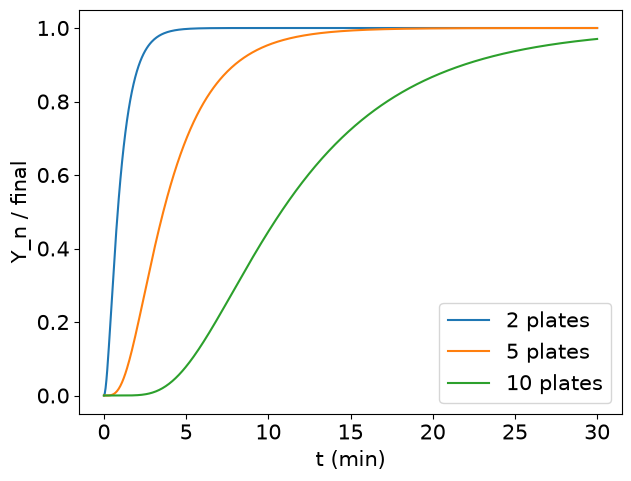

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.25))
t = np.linspace(0, 30, 600)
for n in [2, 5, 10]:
    A = -a_*np.eye(n) + b_*np.eye(n, k=1) + c_*np.eye(n, k=-1)
    B = np.zeros((n, 1)); B[0, 0] = c_      # x0 enters plate 1
    Cm = np.zeros((1, n)); Cm[0, -1] = 1    # read the top plate
    sys = ct.ss(A, B, Cm, 0)
    y = ct.step_response(sys, t).outputs / ct.dcgain(sys)
    ax.plot(t, y, label=f"{n} plates")
ax.set(xlabel="t (min)", ylabel="Y_n / final"); ax.legend(); plt.show()

**Code walkthrough.** `np.eye(n, k=1)` puts ones on the first superdiagonal, `k=-1` on the
first subdiagonal: three lines build the tridiagonal A. B injects the
inlet gas at plate 1, Cm reads the top plate; `ct.ss` makes a
state-space model (Lecture 12 covers it fully). Each curve is divided
by its steady-state gain (`ct.dcgain`). More plates: a longer S-shaped
delay before the outlet responds, and a slower approach (the slowest
eigenvalue is -0.15 per min for 10 plates) -- the higher-order behaviour Ch. 18 approximated by
FOPDT.

### Your Turn (6 min)

1. By hand: why can $\zeta$ never be less than 1 for this absorber?
2. Read the code: what does this print?

```python
print(np.eye(3, k=1))
```

(1) zeta = 1/sqrt(1 - bc/a^2) and 0 < bc/a^2 < 1 (b, c > 0 and
a = b + c, so a^2 > bc): the square root is below 1.
(2) [[0. 1. 0.] [0. 0. 1.] [0. 0. 0.]]: ones just above the diagonal.

### Check -- think-pair-share

The model assumes every plate is an ideal stage. Which conclusion would
change first if the Murphree efficiency were 60%: the order of the
response, its gain, or its damping?

The gain (and the time constants): less ammonia absorbed per plate,
so more reaches the outlet. The structure -- n coupled first-order
plates, real poles -- stays; the order and overdamped character
survive.

## Part C
### Distributed Parameters: the Heat Exchanger

(Coughanowr & LeBlanc, Ch. 20, Sec. 20.3)
<!-- source: coughanowr-ch20 -->

### Introduce -- temperature varies along the tube (Fig. 20-10)

- Steam outside at $T_v(t)$; water inside at velocity $v$.
- Balance on a slice $\Delta x$ (Eq. 20.55):
  $\dfrac{\partial T}{\partial t} = -v\dfrac{\partial T}{\partial x}
  + \dfrac{T_v - T}{\tau}$, $\ \dfrac1\tau = \dfrac{\pi D_iU_i}{A_i\rho C}$.
- A **partial** differential equation: capacity and resistance spread
  along the tube.
- Ex. 20.1: 40-ft tube, $v = 2.4$ ft/s, $\tau = 27.3$ s; $70 \to 212$ F.

### Derive 1/2 -- steady profile (Eq. 20.59)

Set $\partial T/\partial t = 0$ and integrate in $x$:

$$T_s(x) = T_{vs} + (T_{s0} - T_{vs})e^{-x/v\tau}$$

Ex. 20.1: $T_s(40) = 212 - 142e^{-40/65.5} = 134.9$ F.

### Derive 2/2 -- the transfer functions (Eq. 20.65)

Laplace in $t$, then solve the ODE in $x$; $\tau_d = L/v = 16.7$ s, $K = e^{-\tau_d/\tau}$:

$$T'(L,s) = \frac{1 - Ke^{-\tau_ds}}{\tau s + 1}T_v'(s)
+ Ke^{-\tau_ds}\,T'(0,s)$$

Inlet step of 10 F: a **pure delay**, $5.43\,u(t - 16.7)$.
Lumping into $n$ tanks: $(1 + \tau_ds/n)^{-n} \to e^{-\tau_ds}$.

### Code 1/3 -- method of lines

- Cut the tube into $N$ cells; each is a stirred tank (upwind difference)
- The PDE becomes $N$ ODEs for `solve_ivp`

In [8]:
v, tau, L = 2.4, 27.3, 40.0
td, K = L / v, np.exp(-L / v / tau)
def exchanger(N, Tin, Tv, t_end=80):
    dx = L / N
    def rhs(t, T):
        up = np.concatenate([[Tin(t)], T[:-1]])   # upstream cell
        return -v * (T - up) / dx + (Tv(t) - T) / tau
    return solve_ivp(rhs, (0, t_end), np.zeros(N), method="BDF",
                     t_eval=np.linspace(0, t_end, 401))
print(f"td = {td:.1f} s, K = {K:.3f}, Ts(L) = "
      f"{212 - 142 * np.exp(-L / (v * tau)):.1f} F")

td = 16.7 s, K = 0.543, Ts(L) = 134.9 F


**Code walkthrough.** Each cell i gets -v (T_i - T_(i-1))/dx: the flow carries the upstream
temperature in (`up` shifts the array by one and puts the inlet value
first). The heat-transfer term is Eq. 20.55's. Deviation variables, so
the start is zeros. BDF is an implicit solver suited to many coupled
ODEs. Prints td = 16.7 s, K = 0.543, Ts(L) = 134.9 F (Derive 1/2).

### Code 2/3 -- inlet step: lumps versus the delay

- 10 F inlet step, steam constant; $N = 10, 50, 400$ cells

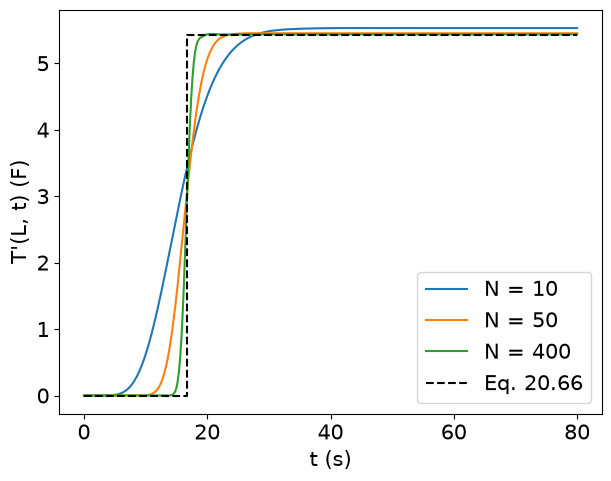

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.25))
for N in [10, 50, 400]:
    r = exchanger(N, lambda t: 10.0, lambda t: 0.0)
    ax.plot(r.t, r.y[-1], label=f"N = {N}")
ax.plot([0, td, td, 80], [0, 0, 10 * K, 10 * K], "k--",
        label="Eq. 20.66")
ax.set(xlabel="t (s)", ylabel="T'(L, t) (F)"); ax.legend(); plt.show()

**Code walkthrough.** `r.y[-1]` is the last cell: the outlet. The black dashed line is the
exact answer, a 5.43 F step delayed 16.7 s. Ten cells give a smooth
S-curve that starts responding early and settles slightly high (5.53:
the lumped gain is (1 + dx/(v tau))^(-N), not e^(-td/tau)); 400 cells nearly
reproduce the sharp delayed step. This is Derive 2/2's limit,
(1 + td s/n)^(-n) -> e^(-td s), seen in a simulation.

### Build on it -- the steam step against Eq. 20.67

- 10 F steam step, inlet constant; 200 cells against the formula

In [ ]:
r = exchanger(200, lambda t: 0.0, lambda t: 10.0)
exact = (10 * (1 - np.exp(-r.t / tau))
         - 10 * K * (1 - np.exp(-np.clip(r.t - td, 0, None) / tau)))
print(f"max |error| = {np.abs(r.y[-1] - exact).max():.3f} F, "
      f"final {exact[-1]:.2f} F")

**Code walkthrough.** `exact` is the book's inverted Eq. 20.67: a first-order rise minus a
delayed first-order term. `np.clip` makes the second term zero before
td. Max error 0.082 F; final 4.57 F (10 - 5.43). A 10 F steam change
moves the outlet by less than half, because water near the outlet
already sits close to the steam temperature.

### Your Turn (8 min)

1. By hand: Prob. 20.2 -- why does a 10 F inlet step raise the outlet
   by only 5.43 F?
2. Read the code: what does this return?

```python
T = np.array([1.0, 2.0, 3.0])
np.concatenate([[9.0], T[:-1]])
```

(1) The outlet sits at the steam temperature minus a decaying
difference; a hotter inlet takes up less heat along the way. The extra
10 F decays like the inlet-to-steam difference, by K = e^(-td/tau) =
0.543.
(2) array([9., 1., 2.]): each cell sees its upstream neighbour, the
first one sees the inlet.

### Check -- poll

The exchanger's phase lag grows without limit as $\omega \to \infty$
(Eq. 20.53 for the slab is similar). Does an $N$-cell lumped model
have that property?

**A)** yes  **B)** no, it stops at $-N\times 90^\circ$

B. N first-order lags give at most -90 N deg. Lumped (minimum-phase)
models have bounded phase; distributed ones do not. For control near
the crossover, enough cells are needed to get the phase right there.

## Part D
### Simulator, Black Box or Grey Box?

(Coughanowr & LeBlanc, Ch. 20, Sec. 20.3)
<!-- source: coughanowr-ch20 -->

### Introduce -- when the physics is almost right

- The "plant": Ex. 20.1's exchanger, but $h_i \propto v^{0.8}$, so
  $U$ grows with flow (an assumption of this example).
- Our model, Eq. 20.59, assumes $U$ constant.
- Three choices, trained on flows $1.5$-$3$ ft/s, tested at $3.5$-$5$:
- **Physics** only; **black box** (regressor on $v, T_{in}, T_v$);
  **grey box**: keep Eq. 20.59's structure, learn only
  $NTU(v) = L/(v\tau)$ from data.

### Derive 1/1 -- the grey-box feature

Rearrange Eq. 20.59 at $x = L$:

$$NTU = -\ln\frac{T_L - T_v}{T_{in} - T_v}$$

Each measurement gives one $NTU$. If $U \propto v^{0.8}$ then
$NTU \propto v^{-0.2}$, so $\ln NTU$ is **linear in** $\ln v$:
ordinary linear regression.

### Code 1/3 -- the plant as a data generator

- 200 noisy steady states for training, 100 at higher flows for test

In [11]:
rng = np.random.default_rng(1)
def plant(v, Tin, Tv):                    # U grows with velocity
    return Tv + (Tin - Tv) * np.exp(-L / (v * 27.3 * (2.4 / v)**0.8))
def draw(n, lo, hi):
    X = np.column_stack([rng.uniform(lo, hi, n), rng.uniform(60, 80, n),
                         rng.uniform(200, 230, n)])
    return X, plant(*X.T)
Xtr, ytr = draw(200, 1.5, 3.0); ytr = ytr + 0.2*rng.standard_normal(200)
Xte, yte = draw(100, 3.5, 5.0)
print(Xtr[:2].round(2), ytr[:2].round(2))

[[  2.27  71.24 228.41]
 [  2.93  67.76 228.85]] [143.03 139.19]


**Code walkthrough.** `plant` is Eq. 20.59 at x = L with tau scaled by (2.4/v)^0.8: at
v = 2.4 it is the book's exchanger. `draw` makes n random operating
points (columns v, Tin, Tv) and the outlet temperatures; `plant(*X.T)`
passes the three columns as the three arguments. Training data get
0.2 F of measurement noise; test data come from higher flows, never
seen in training.

### Code 2/3 -- three models

- Physics with constant $U$; random forest; grey box (Derive 1/1)

In [12]:
def physics(X):
    return X[:, 2] + (X[:, 1] - X[:, 2]) * np.exp(-L / (X[:, 0]*27.3))
rf = RandomForestRegressor(300, random_state=0).fit(Xtr, ytr)
vs, Ti_, Tv_ = Xtr.T                     # vs: velocities
ntu = -np.log((ytr - Tv_) / (Ti_ - Tv_))
g = LinearRegression().fit(np.log(vs)[:, None], np.log(ntu))
def grey(X):
    ntu = np.exp(g.predict(np.log(X[:, :1])))
    return X[:, 2] + (X[:, 1] - X[:, 2]) * np.exp(-ntu)
print(f"learned exponent {g.coef_[0]:.3f}")

learned exponent -0.200


**Code walkthrough.** `physics` is Eq. 20.59 with the design tau = 27.3 s at every flow. The
forest learns outlet temperature directly from the three inputs. The
grey box computes NTU for each training point, regresses ln NTU on
ln v (`[:, None]` makes the column 2-D, as scikit-learn needs), and
plugs the learned NTU back into the physical structure. The learned
exponent is -0.200: the v^-0.2 of Derive 1/1, recovered from noisy
data.

### Code 3/3 -- test at unseen flows

- Root-mean-square error on the high-flow test set

In [ ]:
rmse = lambda p: np.sqrt(np.mean((p - yte)**2))
for name, p in [("physics", physics(Xte)), ("forest", rf.predict(Xte)),
                ("grey box", grey(Xte))]:
    print(f"{name:9s} RMSE = {rmse(p):6.2f} F")

**Code walkthrough.** Each model predicts the outlet at the 100 high-flow test points.
Physics: 18.47 F -- right structure, wrong U at high flow. Forest:
about 4.3 F -- it cannot extrapolate beyond the training flows
(Lecture 10). Grey box: 0.03 F -- the structure carries the
extrapolation, the data supply the one thing the physics lacked.

### Your Turn (6 min)

Read the code: what does each line print?

```python
X = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(X[:, :1].shape, X[:, 2], X.T[0])
```

Why does `grey` use `X[:, :1]` rather than `X[:, 0]`?

(2, 1) [3. 6.] [1. 4.]. X[:, :1] keeps a 2-D column, which
`g.predict` requires; X[:, 0] would be a 1-D array of shape (2,).

### Check -- cold-call

The grey box did well here because the true plant matched its
structure. Name one way it could fail on a real exchanger.

If the structure is wrong: e.g. fouling that varies along the tube,
a steam side that is not at uniform temperature, or a heat-transfer
coefficient that also depends on temperature. Then the learned NTU(v)
absorbs the error and extrapolates it. Check the residuals.

### Wrap-up

**Derived, then coded:** multivariable linearization of the kettle and
the positive loop between its steam and water sides; the absorber's
overdamped transfer function and its $n$-plate matrix; the exchanger
PDE, its steady profile and transfer functions, solved by the method
of lines; physics, black-box and grey-box models compared outside
their data.

**Tools:** `sp.diff`, `sp.solve`, `ct.feedback(sign=1)`, `np.eye(k=)`,
`ct.ss`, `solve_ivp(method="BDF")`, `LinearRegression`

**Next:** Ch. 21-22 -- state-space methods.